<a href="https://colab.research.google.com/github/Almat-nag/deep-learning-final-project/blob/master/notebooks/week4_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets -q

import os
import re
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

os.makedirs("results", exist_ok=True)

Device: cuda


In [ ]:
dataset = load_dataset("m375zhan/modified_jigsaw_toxic_comment_classification_challenge")
df = dataset["train"].to_pandas()

TEXT_COLUMN = "text"

target_columns = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

print("Dataset shape:", df.shape)
display(df.head())

print("Missing values:")
print(df[[TEXT_COLUMN] + target_columns].isnull().sum())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/527 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/43.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/159571 [00:00<?, ? examples/s]

Dataset shape: (159571, 8)


,id,text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


Missing values:
text             0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


Label distribution:
toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


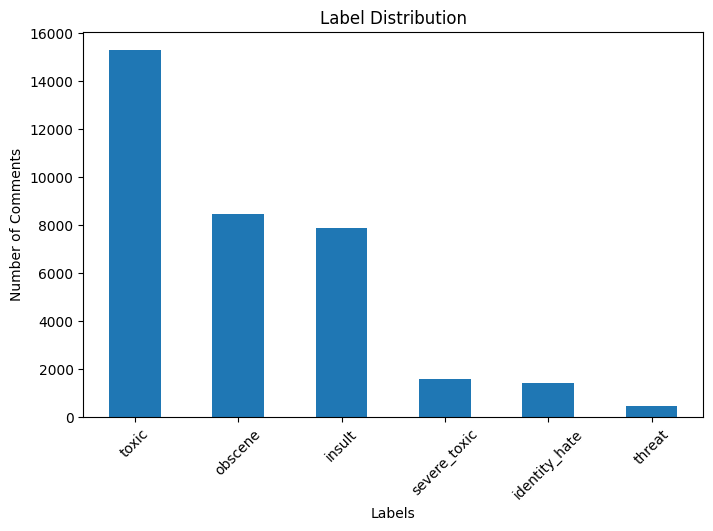

In [ ]:
label_counts = df[target_columns].sum().sort_values(ascending=False)

print("Label distribution:")
print(label_counts)

plt.figure(figsize=(8, 5))
label_counts.plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Labels")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.show()

Text length statistics:
count    159571.000000
mean         67.273527
std          99.230702
min           1.000000
25%          17.000000
50%          36.000000
75%          75.000000
max        1411.000000
Name: text_length, dtype: float64


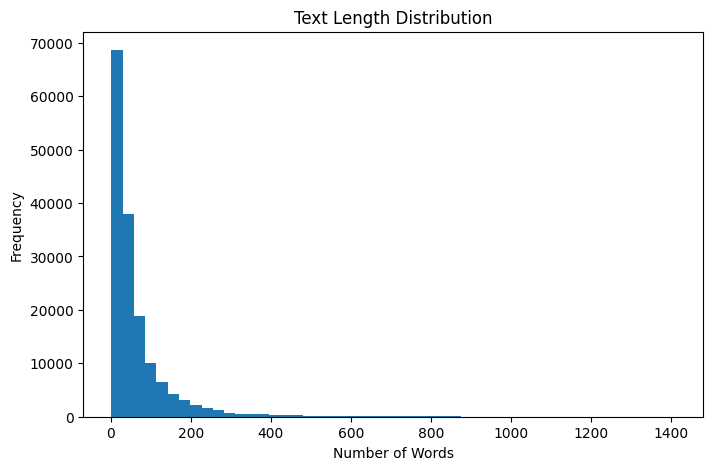

In [ ]:
df["text_length"] = df[TEXT_COLUMN].apply(lambda x: len(str(x).split()))

print("Text length statistics:")
print(df["text_length"].describe())

plt.figure(figsize=(8, 5))
plt.hist(df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# text cleaninig
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df[TEXT_COLUMN].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,Explanation\nWhy the edits made under my usern...,explanation why the edits made under my userna...
1,D'aww! He matches this background colour I'm s...,d aww he matches this background colour i m se...
2,"Hey man, I'm really not trying to edit war. It...",hey man i m really not trying to edit war it s...
3,"""\nMore\nI can't make any real suggestions on ...",more i can t make any real suggestions on impr...
4,"You, sir, are my hero. Any chance you remember...",you sir are my hero any chance you remember wh...


In [ ]:
# Train / Validation / Test Split
X = df["clean_text"].values
y = df[target_columns].values.astype(np.float32)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED
)

print("Original train size:", len(X_train))
print("Original validation size:", len(X_val))
print("Original test size:", len(X_test))

# reduce size for faster training
X_train_small = X_train[:30000]
y_train_small = y_train[:30000]

X_val_small = X_val[:5000]
y_val_small = y_val[:5000]

print("Reduced train size:", len(X_train_small))
print("Reduced validation size:", len(X_val_small))

Original train size: 127656
Original validation size: 15957
Original test size: 15958
Reduced train size: 30000
Reduced validation size: 5000


In [ ]:
# Week 2: Baseline Model
tfidf = TfidfVectorizer(
    max_features=50000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train_small)
X_val_tfidf = tfidf.transform(X_val_small)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF validation shape:", X_val_tfidf.shape)

TF-IDF train shape: (30000, 50000)
TF-IDF validation shape: (5000, 50000)


In [ ]:
baseline_model = MultiOutputClassifier(MultinomialNB())
baseline_model.fit(X_train_tfidf, y_train_small)

baseline_pred = baseline_model.predict(X_val_tfidf)

baseline_probs = np.zeros_like(y_val_small, dtype=float)

for i, estimator in enumerate(baseline_model.estimators_):
    baseline_probs[:, i] = estimator.predict_proba(X_val_tfidf)[:, 1]

baseline_results = []

for i, label in enumerate(target_columns):
    roc_auc = roc_auc_score(y_val_small[:, i], baseline_probs[:, i])
    precision = precision_score(y_val_small[:, i], baseline_pred[:, i], zero_division=0)
    recall = recall_score(y_val_small[:, i], baseline_pred[:, i], zero_division=0)
    f1 = f1_score(y_val_small[:, i], baseline_pred[:, i], zero_division=0)
    accuracy = accuracy_score(y_val_small[:, i], baseline_pred[:, i])

    baseline_results.append({
        "label": label,
        "roc_auc": roc_auc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "accuracy": accuracy
    })

baseline_results_df = pd.DataFrame(baseline_results)
display(baseline_results_df)

baseline_avg = baseline_results_df[
    ["roc_auc", "precision", "recall", "f1_score", "accuracy"]
].mean()

print("Baseline average:")
display(baseline_avg)

,label,roc_auc,precision,recall,f1_score,accuracy
0,toxic,0.897053,1.000000,0.175869,0.299130,0.9194
1,severe_toxic,0.938911,0.000000,0.000000,0.000000,0.9896
2,obscene,0.914875,0.974359,0.147287,0.255892,0.9558
3,threat,0.818899,0.000000,0.000000,0.000000,0.9976
4,insult,0.902240,1.000000,0.067460,0.126394,0.9530
5,identity_hate,0.817192,0.000000,0.000000,0.000000,0.9908


Baseline average:


,0
roc_auc,0.881528
precision,0.495726
recall,0.065103
f1_score,0.113569
accuracy,0.967700


In [ ]:
MAX_VOCAB_SIZE = 30000
MAX_LEN = 200

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

counter = Counter()

for text in X_train_small:
    counter.update(text.split())

most_common_words = counter.most_common(MAX_VOCAB_SIZE - 2)

word2idx = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}

for word, _ in most_common_words:
    word2idx[word] = len(word2idx)

VOCAB_SIZE = len(word2idx)

print("Vocabulary size:", VOCAB_SIZE)

Vocabulary size: 30000


In [ ]:
def encode_text(text, word2idx, max_len):
    tokens = str(text).split()
    ids = [word2idx.get(token, word2idx[UNK_TOKEN]) for token in tokens]

    if len(ids) < max_len:
        ids = ids + [word2idx[PAD_TOKEN]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]

    return ids

X_train_encoded = np.array([
    encode_text(text, word2idx, MAX_LEN) for text in X_train_small
])

X_val_encoded = np.array([
    encode_text(text, word2idx, MAX_LEN) for text in X_val_small
])

print("Encoded train shape:", X_train_encoded.shape)
print("Encoded validation shape:", X_val_encoded.shape)

Encoded train shape: (30000, 200)
Encoded validation shape: (5000, 200)


In [ ]:
class ToxicCommentsDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = torch.tensor(texts, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

BATCH_SIZE = 64

train_dataset = ToxicCommentsDataset(X_train_encoded, y_train_small)
val_dataset = ToxicCommentsDataset(X_val_encoded, y_val_small)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 469
Validation batches: 79


In [ ]:
class LSTMToxicClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, pad_idx, num_layers=1, dropout=0.3):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx
        )

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)
        last_hidden = hidden[-1]
        dropped = self.dropout(last_hidden)
        logits = self.fc(dropped)
        return logits

model = LSTMToxicClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=128,
    hidden_dim=128,
    output_dim=len(target_columns),
    pad_idx=word2idx[PAD_TOKEN],
    dropout=0.3
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

LSTMToxicClassifier(
  (embedding): Embedding(30000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=6, bias=True)
)


In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for texts, labels in dataloader:
        texts = texts.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(texts)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluate_loss(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for texts, labels in dataloader:
            texts = texts.to(device)
            labels = labels.to(device)

            logits = model(texts)
            loss = criterion(logits, labels)

            total_loss += loss.item()

    return total_loss / len(dataloader)


def get_predictions(model, dataloader, device):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for texts, labels in dataloader:
            texts = texts.to(device)

            logits = model(texts)
            probs = torch.sigmoid(logits).cpu().numpy()

            all_probs.append(probs)
            all_labels.append(labels.numpy())

    return np.vstack(all_labels), np.vstack(all_probs)

In [ ]:
EPOCHS = 3
history = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate_loss(model, val_loader, criterion, device)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss
    })

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print("-" * 40)

history_df = pd.DataFrame(history)
history_df.to_csv("results/week4_training_history.csv", index=False)

display(history_df)

Epoch 1/3
Train Loss: 0.1631
Validation Loss: 0.1426
----------------------------------------
Epoch 2/3
Train Loss: 0.1450
Validation Loss: 0.1420
----------------------------------------
Epoch 3/3
Train Loss: 0.1437
Validation Loss: 0.1417
----------------------------------------


,epoch,train_loss,val_loss
0,1,0.163085,0.142563
1,2,0.144982,0.141990
2,3,0.143690,0.141696


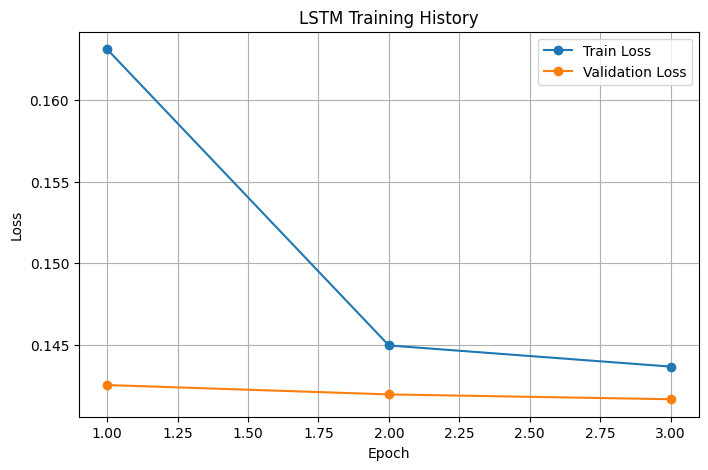

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation Loss")
plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
y_true, y_probs = get_predictions(model, val_loader, device)

thresholds = [0.2, 0.3, 0.4, 0.5]
threshold_results = []

for threshold in thresholds:
    y_pred = (y_probs >= threshold).astype(int)

    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

,threshold,precision,recall,f1_score
0,0.2,0.395238,0.018106,0.033744
1,0.3,0.502778,0.018106,0.034212
2,0.4,0.583333,0.018106,0.034237
3,0.5,0.625000,0.017104,0.032284


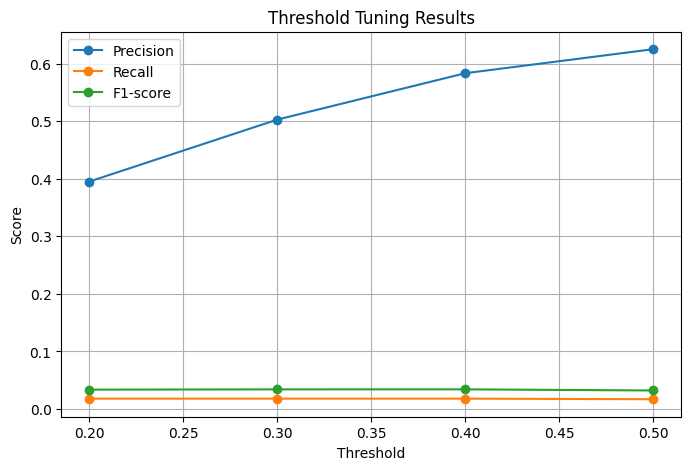

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1_score"], marker="o", label="F1-score")
plt.title("Threshold Tuning Results")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_row = threshold_df.loc[threshold_df["f1_score"].idxmax()]
best_threshold = best_row["threshold"]

print("Best threshold:", best_threshold)
display(best_row)

y_pred_best = (y_probs >= best_threshold).astype(int)

lstm_results = []

for i, label in enumerate(target_columns):
    roc_auc = roc_auc_score(y_true[:, i], y_probs[:, i])
    precision = precision_score(y_true[:, i], y_pred_best[:, i], zero_division=0)
    recall = recall_score(y_true[:, i], y_pred_best[:, i], zero_division=0)
    f1 = f1_score(y_true[:, i], y_pred_best[:, i], zero_division=0)
    accuracy = accuracy_score(y_true[:, i], y_pred_best[:, i])

    lstm_results.append({
        "label": label,
        "roc_auc": roc_auc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "accuracy": accuracy
    })

lstm_results_df = pd.DataFrame(lstm_results)
display(lstm_results_df)

lstm_avg = lstm_results_df[
    ["roc_auc", "precision", "recall", "f1_score", "accuracy"]
].mean()

print("LSTM average:")
display(lstm_avg)

Best threshold: 0.4


,2
threshold,0.400000
precision,0.583333
recall,0.018106
f1_score,0.034237


,label,roc_auc,precision,recall,f1_score,accuracy
0,toxic,0.544730,1.00,0.008180,0.016227,0.9030
1,severe_toxic,0.583938,1.00,0.076923,0.142857,0.9904
2,obscene,0.552385,0.75,0.011628,0.022901,0.9488
3,threat,0.579691,0.00,0.000000,0.000000,0.9968
4,insult,0.596447,0.75,0.011905,0.023438,0.9500
5,identity_hate,0.543175,0.00,0.000000,0.000000,0.9900


LSTM average:


,0
roc_auc,0.566728
precision,0.583333
recall,0.018106
f1_score,0.034237
accuracy,0.963167


In [ ]:
comparison_df = pd.DataFrame([
    {
        "model": "Week 2 TF-IDF + Naive Bayes",
        "roc_auc": baseline_avg["roc_auc"],
        "precision": baseline_avg["precision"],
        "recall": baseline_avg["recall"],
        "f1_score": baseline_avg["f1_score"],
        "accuracy": baseline_avg["accuracy"]
    },
    {
        "model": "Week 4 LSTM + Threshold Tuning",
        "roc_auc": lstm_avg["roc_auc"],
        "precision": lstm_avg["precision"],
        "recall": lstm_avg["recall"],
        "f1_score": lstm_avg["f1_score"],
        "accuracy": lstm_avg["accuracy"]
    }
])

display(comparison_df)

comparison_df.to_csv("results/week4_model_comparison.csv", index=False)
threshold_df.to_csv("results/week4_threshold_tuning_results.csv", index=False)
baseline_results_df.to_csv("results/week4_baseline_results.csv", index=False)
lstm_results_df.to_csv("results/week4_lstm_results.csv", index=False)

,model,roc_auc,precision,recall,f1_score,accuracy
0,Week 2 TF-IDF + Naive Bayes,0.881528,0.495726,0.065103,0.113569,0.967700
1,Week 4 LSTM + Threshold Tuning,0.566728,0.583333,0.018106,0.034237,0.963167


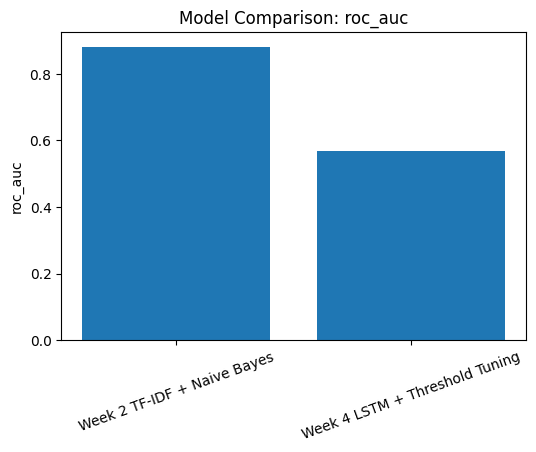

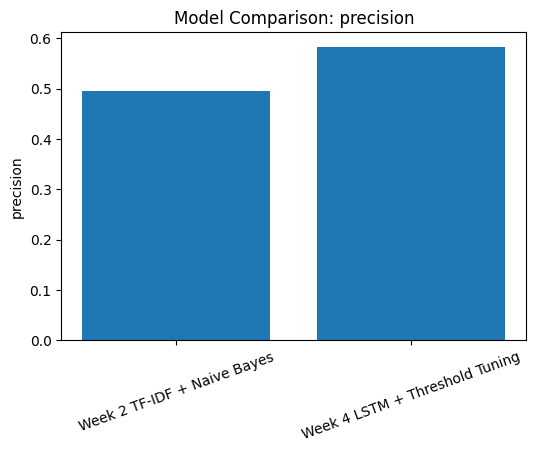

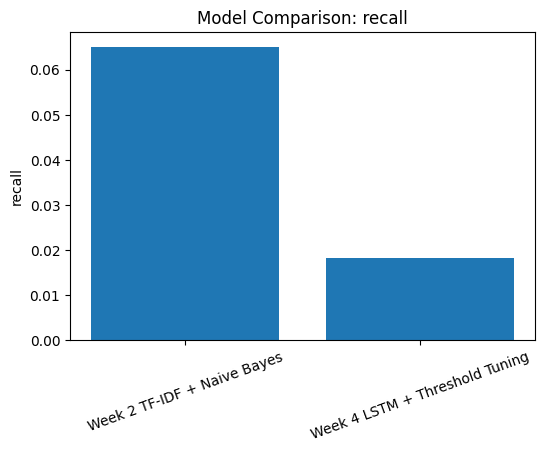

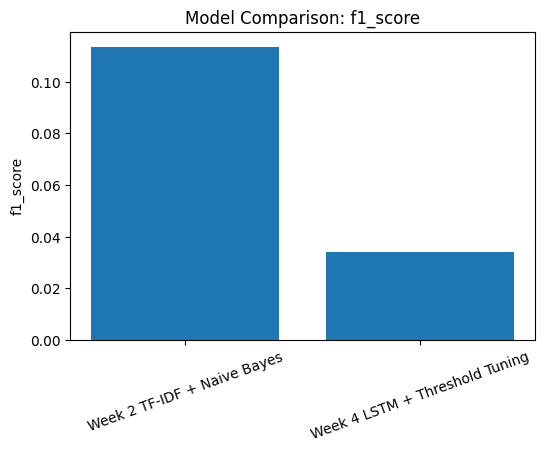

In [ ]:
metrics = ["roc_auc", "precision", "recall", "f1_score"]

for metric in metrics:
    plt.figure(figsize=(6, 4))
    plt.bar(comparison_df["model"], comparison_df[metric])
    plt.title(f"Model Comparison: {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.show()

In [ ]:
error_examples = []

for i in range(len(y_true)):
    if not np.array_equal(y_true[i], y_pred_best[i]):
        error_examples.append({
            "text": X_val_small[i],
            "true_labels": y_true[i].tolist(),
            "predicted_labels": y_pred_best[i].tolist()
        })

    if len(error_examples) >= 10:
        break

error_df = pd.DataFrame(error_examples)
display(error_df)

error_df.to_csv("results/week4_error_analysis.csv", index=False)

,text,true_labels,predicted_labels
0,one translation you are an impotent fucker,"[1.0, 0.0, 1.0, 0.0, 1.0, 0.0]","[0, 0, 0, 0, 0, 0]"
1,my ip changes daily you dumb bozo there s no w...,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0]","[0, 0, 0, 0, 0, 0]"
2,fuck you fuck you fuck you fuck you fuck you f...,"[1.0, 1.0, 1.0, 0.0, 1.0, 0.0]","[1, 1, 1, 1, 1, 1]"
3,merge or delete what the hell,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0, 0, 0, 0, 0, 0]"
4,omg i thought the last freak was a fucking ner...,"[1.0, 0.0, 1.0, 0.0, 0.0, 0.0]","[0, 0, 0, 0, 0, 0]"
5,p s i need some penis cat tongue is getting old,"[1.0, 0.0, 1.0, 0.0, 0.0, 0.0]","[0, 0, 0, 0, 0, 0]"
6,mine ur own fucking bussiness wat da fuck is u...,"[1.0, 1.0, 1.0, 0.0, 1.0, 0.0]","[0, 0, 0, 0, 0, 0]"
7,wikipedia is useless you idiots defie the laws...,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0, 0, 0, 0, 0, 0]"
8,uhhhh you don t own this site so don t touch m...,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0, 0, 0, 0, 0, 0]"
9,you are a tattletale douchebag,"[1.0, 0.0, 1.0, 0.0, 1.0, 0.0]","[0, 0, 0, 0, 0, 0]"


In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "word2idx": word2idx,
    "target_columns": target_columns,
    "max_len": MAX_LEN,
    "best_threshold": best_threshold
}, "results/final_lstm_model.pt")

print("Final model saved to results/final_lstm_model.pt")

Final model saved to results/final_lstm_model.pt
